# Temporal drift validation

How much does the model's predictive accuracy degrade as we move forward in time from the training data? Unlike `validation.ipynb` (which asks *"which model is best"* on a held-out test set), this notebook asks *"how quickly does that answer change"*.

**Split**: chronological 25/75. The oldest 25% of teams (by tournament date) form the training set; the newest 75% form the test set, sliced into equal-tournament-count windows. This deliberately under-trains compared to `validation.ipynb`'s 90/10 — absolute accuracy drops, but we get enough temporal range to see drift, shocks, and model-vs-model decay rates. Relative model differences are what matter, not absolute hit rates.

**Useful for**:
- Setting expectations on how often the model needs to be re-fit.
- Distinguishing **gradual drift** (slow metagame evolution → linear-ish decay) from **shocks** (a new top-tier team is discovered → sudden drop at one window).
- Cross-checking the headline cross-model numbers: if Phase 3's edge is purely a feature-richness effect, it should persist under temporal split; if it's partly a memorization artifact, it'll degrade faster than Phase 2.

**Models compared**: co-occurrence (control — also drifts, separates "model drifts" from "meta is just less predictable"), Phase 2 species Ising, Phase 3 pair Ising. Three models give the cleanest story without crowding the plot.

In [1]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from k2dex import helpers, limitless_ingest
from k2dex.constants import (
    DRIFT_TRAIN_FRAC, PHASE2_MIN_TEAM_COUNT,
    SPECIES_LR_C, SPECIES_ITEM_LR_C,
)
from k2dex.models import fit_pl_ising

tournaments = limitless_ingest.ingest()
print(f"tournaments:            {len(tournaments)}")
print(f"total team-appearances: {sum(len(t.teams) for t in tournaments)}")

tournaments:            71
total team-appearances: 14506


## Chronological 25/75 split

Oldest 25% of teams (by tournament boundary) → train. The remaining 75% is sliced into $N$ equal-tournament-count windows for per-window evaluation.

The low train fraction is deliberate: we sacrifice absolute accuracy to buy a wide temporal window. If the signal is robust enough to survive 25% training data, it's real; if model separation vanishes, that tells us the edge is fragile and data-hungry.

In [2]:
N_WINDOWS = 8

train_tournaments, test_tournaments = limitless_ingest.chronological_split(
    tournaments, train_frac=DRIFT_TRAIN_FRAC,
)

n_train_teams = sum(len(t.teams) for t in train_tournaments)
n_test_teams = sum(len(t.teams) for t in test_tournaments)
n_total = n_train_teams + n_test_teams

print(
    f"train (oldest {DRIFT_TRAIN_FRAC:.0%}): {len(train_tournaments)} tournaments, "
    f"{n_train_teams} teams ({n_train_teams/n_total:.1%})\n"
    f"  {train_tournaments[0].meta.date} -> {train_tournaments[-1].meta.date}\n"
    f"test  (newest {1 - DRIFT_TRAIN_FRAC:.0%}): {len(test_tournaments)} tournaments, "
    f"{n_test_teams} teams ({n_test_teams/n_total:.1%})\n"
    f"  {test_tournaments[0].meta.date} -> {test_tournaments[-1].meta.date}"
)

# Slice test tournaments into N equal-count windows; last absorbs remainder.
window_size = len(test_tournaments) // N_WINDOWS
windows = []
for i in range(N_WINDOWS):
    start = i * window_size
    end = (i + 1) * window_size if i < N_WINDOWS - 1 else len(test_tournaments)
    windows.append(test_tournaments[start:end])

print(f"\n{N_WINDOWS} test windows ({window_size} tournaments each):")
for i, w in enumerate(windows):
    teams_in_window = sum(len(t.teams) for t in w)
    print(
        f"  window {i}: {w[0].meta.date} -> {w[-1].meta.date}   "
        f"({len(w)} tournaments, {teams_in_window} teams)"
    )

train (oldest 25%): 28 tournaments, 3671 teams (25.3%)
  2026-04-09T16:00:00.000Z -> 2026-04-19T01:00:00.000Z
test  (newest 75%): 43 tournaments, 10835 teams (74.7%)
  2026-04-19T13:00:00.000Z -> 2026-05-25T01:00:00.000Z

8 test windows (5 tournaments each):
  window 0: 2026-04-19T13:00:00.000Z -> 2026-04-20T17:00:00.000Z   (5 tournaments, 428 teams)
  window 1: 2026-04-20T21:30:00.000Z -> 2026-04-23T15:00:00.000Z   (5 tournaments, 439 teams)
  window 2: 2026-04-23T23:00:00.000Z -> 2026-04-25T16:00:00.000Z   (5 tournaments, 6648 teams)
  window 3: 2026-04-26T01:00:00.000Z -> 2026-04-29T15:00:00.000Z   (5 tournaments, 431 teams)
  window 4: 2026-04-29T22:00:00.000Z -> 2026-05-02T15:00:00.000Z   (5 tournaments, 682 teams)
  window 5: 2026-05-02T17:45:00.000Z -> 2026-05-07T23:00:00.000Z   (5 tournaments, 489 teams)
  window 6: 2026-05-09T12:00:00.000Z -> 2026-05-11T20:31:00.000Z   (5 tournaments, 746 teams)
  window 7: 2026-05-13T22:00:00.000Z -> 2026-05-25T01:00:00.000Z   (8 tournaments,

## Train-only vocabs

Both species and pair vocabs are built from the train set only. A species or `(species, item)` pair that only appears in future test tournaments is out-of-vocab — the model fit at time $t$ cannot know about a Pokémon that hadn't been used yet at time $t$.

In [3]:
train_teams_full = limitless_ingest.all_teams(train_tournaments)
train_teams = limitless_ingest.species_only_teams(train_teams_full)

# Species vocab
species_counts = Counter(name for team in train_teams for name in team)
vocab = sorted(name for name, c in species_counts.items() if c >= PHASE2_MIN_TEAM_COUNT)
name_to_idx = {name: i for i, name in enumerate(vocab)}
V = len(vocab)

# Pair vocab
pair_counts = Counter(pair for team in train_teams_full for pair in team)
pair_vocab = sorted(
    (p for p, c in pair_counts.items() if c >= PHASE2_MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
V_pair = len(pair_vocab)

print(f"train species vocab: {V}")
print(f"train pair vocab:    {V_pair}")

train species vocab: 140
train pair vocab:    350


## Model fits (train-only)

In [4]:
def teams_to_matrix(teams, name_to_idx, V):
    X = np.zeros((len(teams), V), dtype=np.int8)
    for ti, team in enumerate(teams):
        for name in team:
            j = name_to_idx.get(name)
            if j is not None:
                X[ti, j] = 1
    return X


# Phase 2 (species) PL fit
X_train_species = teams_to_matrix(train_teams, name_to_idx, V).astype(np.int32)
J_species, h_species = fit_pl_ising(X_train_species, C=SPECIES_LR_C)
print(
    f"Phase 2 J range: "
    f"[{J_species[np.triu_indices(V, 1)].min():+.3f},"
    f" {J_species[np.triu_indices(V, 1)].max():+.3f}]"
)

# Phase 3 (pair) PL fit
X_train_pair = np.zeros((len(train_teams_full), V_pair), dtype=np.int32)
for ti, team in enumerate(train_teams_full):
    for pair in team:
        j = pair_to_idx.get(pair)
        if j is not None:
            X_train_pair[ti, j] = 1

J_pair, h_pair = fit_pl_ising(X_train_pair, C=SPECIES_ITEM_LR_C)
print(
    f"Phase 3 J range: "
    f"[{J_pair[np.triu_indices(V_pair, 1)].min():+.3f},"
    f" {J_pair[np.triu_indices(V_pair, 1)].max():+.3f}]"
)

# Co-occurrence baseline
C_train = (X_train_species.T @ X_train_species).astype(np.float64)
np.fill_diagonal(C_train, 0.0)
print(f"C_train off-diag: max = {int(C_train.max())}, nnz = {int((C_train > 0).sum())}")

Phase 2 J range: [-2.184, +2.869]
Phase 3 J range: [-4.671, +3.719]
C_train off-diag: max = 735, nnz = 8006


## Scoring functions

Same mean-field scoring as `validation.ipynb`. Phase 3 projects pair marginals to species marginals via the mutual-exclusion sum for fair cross-model comparison.

In [5]:
def score_cooccurrence(held_in_species_idx, *, C):
    return C[:, list(held_in_species_idx)].sum(axis=1)


def score_ising_meanfield(held_in_idx, *, J, h, n_iter=50, damp=0.5):
    V = J.shape[0]
    mu = np.full(V, 0.5)
    mu[list(held_in_idx)] = 1.0
    for _ in range(n_iter):
        logit = h + J @ mu
        mu_new = 1.0 / (1.0 + np.exp(-logit))
        mu_new[list(held_in_idx)] = 1.0
        mu = damp * mu + (1 - damp) * mu_new
    return mu


def hit_rate_at_k(ranks, K):
    return float((ranks <= K).mean())


def mrr(ranks):
    return float((1.0 / ranks).mean())

## Per-window leave-1-out evaluation

For each window: filter test teams to those with all members in both train-only vocabs (so all three models can score them), hold out one species, compute top-K hit rate and MRR.

In [6]:
SEED = 42
DRIFT_K = 1
DRIFT_TOP_K = [1, 5, 10]

# Species -> list of pair indices (for Phase 3 projection)
species_to_pair_idxs: dict[str, list[int]] = {}
for i, (sp, _) in enumerate(pair_vocab):
    species_to_pair_idxs.setdefault(sp, []).append(i)

model_names = ["co-occurrence", "Ising species", "Ising item-pair"]
metrics = {
    name: {"hit_rate": {K: [] for K in DRIFT_TOP_K}, "mrr": [], "n_teams": []}
    for name in model_names
}
window_labels = []
window_dates_center = []

rng = np.random.default_rng(SEED)

for w_idx, window_tournaments in enumerate(windows):
    window_teams_full = limitless_ingest.all_teams(window_tournaments)
    in_vocab_window = []
    for team in window_teams_full:
        if len(team) != 6:
            continue
        if len({s for s, _ in team}) != 6:
            continue
        if not all(s in name_to_idx for s, _ in team):
            continue
        if not all(p in pair_to_idx for p in team):
            continue
        in_vocab_window.append(team)

    label = f"{window_tournaments[0].meta.date[:10]}\n{window_tournaments[-1].meta.date[:10]}"
    window_labels.append(label)
    window_dates_center.append(window_tournaments[len(window_tournaments) // 2].meta.date[:10])

    per_window_ranks = {name: [] for name in model_names}

    for team in in_vocab_window:
        members = sorted(team, key=lambda p: p[0])
        species_idxs = np.array([name_to_idx[s] for s, _ in members])
        pair_idxs = np.array([pair_to_idx[p] for p in members])

        held_out_pos = rng.choice(6, size=DRIFT_K, replace=False)
        held_in_pos = np.delete(np.arange(6), held_out_pos)
        held_out_species_idx = species_idxs[held_out_pos]
        held_in_species_idx = species_idxs[held_in_pos]
        held_in_pair_idx = pair_idxs[held_in_pos]

        # Species-vocab scorers (co-occurrence + Phase 2 Ising)
        for name, score_arr in (
            ("co-occurrence", score_cooccurrence(held_in_species_idx, C=C_train)),
            ("Ising species", score_ising_meanfield(held_in_species_idx, J=J_species, h=h_species)),
        ):
            scores = score_arr.astype(np.float64).copy()
            scores[held_in_species_idx] = -np.inf
            order = np.argsort(-scores)
            rank_of = np.empty(V, dtype=np.int64)
            rank_of[order] = np.arange(1, V + 1)
            per_window_ranks[name].append(rank_of[held_out_species_idx])

        # Phase 3: pair-MF projected to species via mutual-exclusion sum
        pair_marginals = score_ising_meanfield(held_in_pair_idx, J=J_pair, h=h_pair)
        species_scores_p3 = np.zeros(V)
        for j_pair, (sp, _) in enumerate(pair_vocab):
            s_idx = name_to_idx.get(sp)
            if s_idx is None:
                continue
            species_scores_p3[s_idx] += pair_marginals[j_pair]
        species_scores_p3[held_in_species_idx] = -np.inf
        order = np.argsort(-species_scores_p3)
        rank_of = np.empty(V, dtype=np.int64)
        rank_of[order] = np.arange(1, V + 1)
        per_window_ranks["Ising item-pair"].append(rank_of[held_out_species_idx])

    for name in model_names:
        ranks_arr = np.array(per_window_ranks[name])
        if len(ranks_arr) == 0:
            for K in DRIFT_TOP_K:
                metrics[name]["hit_rate"][K].append(np.nan)
            metrics[name]["mrr"].append(np.nan)
            metrics[name]["n_teams"].append(0)
            continue
        for K in DRIFT_TOP_K:
            metrics[name]["hit_rate"][K].append(float((ranks_arr <= K).mean()))
        metrics[name]["mrr"].append(float((1.0 / ranks_arr).mean()))
        metrics[name]["n_teams"].append(len(ranks_arr))

    print(
        f"window {w_idx} ({label.replace(chr(10), ' -> ')}): "
        f"{len(in_vocab_window):>4} in-vocab teams / {len(window_teams_full):>4} total"
    )

window 0 (2026-04-19 -> 2026-04-20):  325 in-vocab teams /  428 total
window 1 (2026-04-20 -> 2026-04-23):  334 in-vocab teams /  439 total
window 2 (2026-04-23 -> 2026-04-25): 4806 in-vocab teams / 6648 total
window 3 (2026-04-26 -> 2026-04-29):  327 in-vocab teams /  431 total
window 4 (2026-04-29 -> 2026-05-02):  499 in-vocab teams /  682 total
window 5 (2026-05-02 -> 2026-05-07):  349 in-vocab teams /  489 total
window 6 (2026-05-09 -> 2026-05-11):  550 in-vocab teams /  746 total
window 7 (2026-05-13 -> 2026-05-25):  696 in-vocab teams /  972 total


## Drift curves

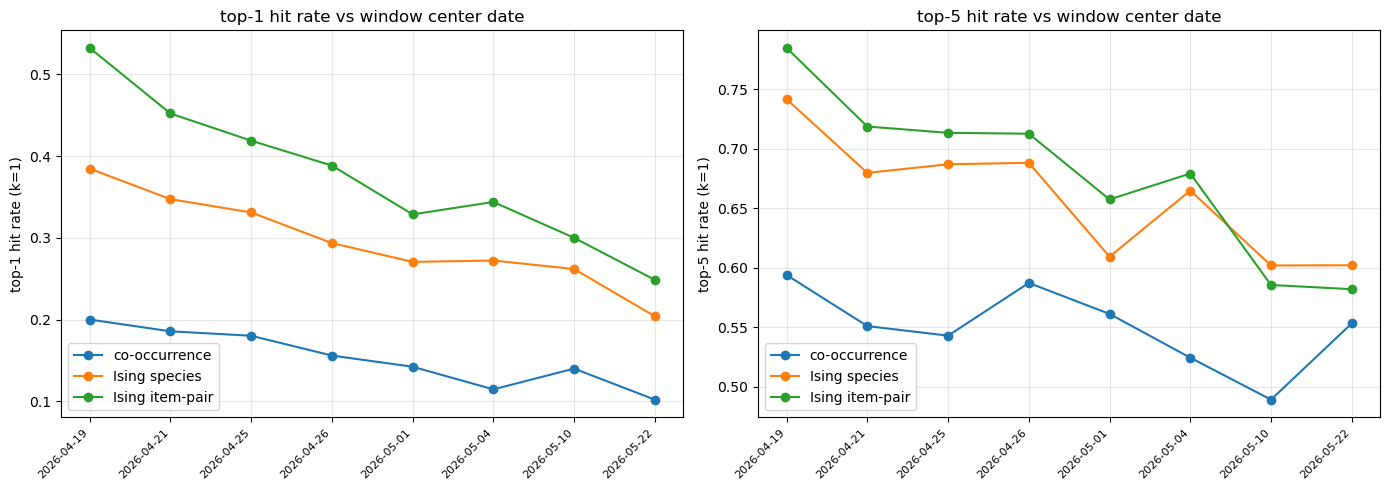

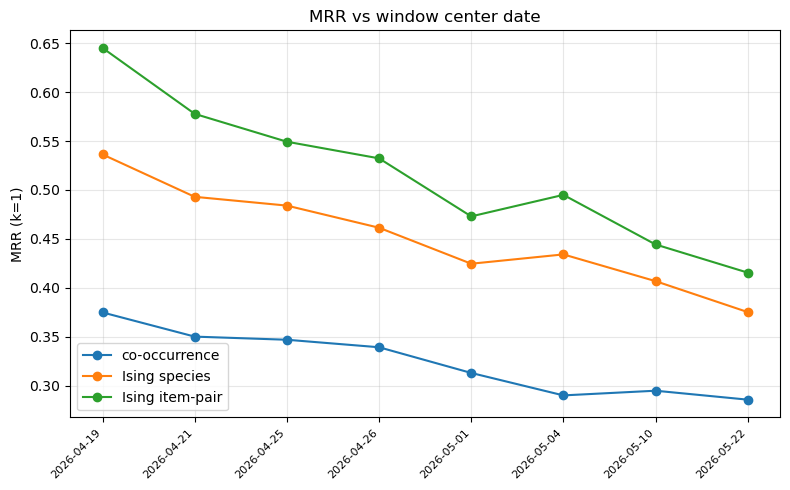

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
x = np.arange(N_WINDOWS)

for ax, K in zip(axes, [1, 5]):
    for name in model_names:
        ax.plot(x, metrics[name]["hit_rate"][K], marker="o", label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(window_dates_center, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(f"top-{K} hit rate (k=1)")
    ax.set_title(f"top-{K} hit rate vs window center date")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
for name in model_names:
    ax2.plot(x, metrics[name]["mrr"], marker="o", label=name)
ax2.set_xticks(x)
ax2.set_xticklabels(window_dates_center, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("MRR (k=1)")
ax2.set_title("MRR vs window center date")
ax2.grid(alpha=0.3)
ax2.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Per-window summary

In [8]:
print(f"{'window':>6}  {'date range':<25}  {'n_teams':>7}  ", end="")
for name in model_names:
    print(f"  {name:>18} top-1", end="")
print()
print("-" * 120)
for i in range(N_WINDOWS):
    date_range = window_labels[i].replace('\n', ' -> ')
    n = metrics[model_names[0]]["n_teams"][i]
    print(f"{i:>6}  {date_range:<25}  {n:>7}  ", end="")
    for name in model_names:
        hr = metrics[name]["hit_rate"][1][i]
        print(f"  {hr:>22.1%}", end="")
    print()

window  date range                 n_teams         co-occurrence top-1       Ising species top-1     Ising item-pair top-1
------------------------------------------------------------------------------------------------------------------------
     0  2026-04-19 -> 2026-04-20       325                     20.0%                   38.5%                   53.2%
     1  2026-04-20 -> 2026-04-23       334                     18.6%                   34.7%                   45.2%
     2  2026-04-23 -> 2026-04-25      4806                     18.0%                   33.1%                   41.9%
     3  2026-04-26 -> 2026-04-29       327                     15.6%                   29.4%                   38.8%
     4  2026-04-29 -> 2026-05-02       499                     14.2%                   27.1%                   32.9%
     5  2026-05-02 -> 2026-05-07       349                     11.5%                   27.2%                   34.4%
     6  2026-05-09 -> 2026-05-11       550            

## Interpretation

What the curves typically tell us:

- **All three lines drift downward together**: the meta is genuinely shifting, and *no* fixed model captures the new state. Distance between lines tells you which model degrades fastest.
- **A sharp drop in one window**: candidate for a meta shock — a new team archetype was discovered that hadn't shown up enough in training to register. Cross-reference the dates against community events / format announcements.
- **Ising species drifts faster than Ising item-pair (or vice versa)**: gap-stability tells you which feature granularity is more robust to meta evolution. Item-pair degrading faster would be a memorization signal (more features, less per-feature data, more capacity to overfit to specific roster choices that don't survive). Species degrading faster would mean item-pair is capturing more time-stable structure.
- **All three lines hold roughly flat**: meta is stable across the test window and the train parameters generalize fine. Less interesting as a result but a useful null — confirms no systematic harness bug producing apparent decay.
- **Co-occurrence drifts least**: counts are robust summary statistics; the Ising models' edge comes from fitting *patterns* that are more sensitive to which patterns happen to be in style. This would suggest the Ising win is more "compression of current meta" than "discovery of timeless structure."

To go further: re-cut the experiment with the train half ending at a *known* event (a major regulation update, a Pokémon Champions patch, a high-profile tournament result going viral) and check whether the drop in the first post-event window is larger than the drift between adjacent windows otherwise. That's the cleanest test of "model detects shock vs. drift."